In [9]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
import  scipy
import pickle
import matplotlib.pyplot as plt
import sys
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colors as mcolors
sys.path.append("../") 
import WRFDomainLib

mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)



In [35]:
file0='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/percentiles/pr25p_hist_roll29.nc'

In [36]:
ds = xr.open_dataset(file0)

In [37]:
ds

<xarray.Dataset> Size: 265MB
Dimensions:    (dayofyear: 366, lon: 300, lat: 300)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
    lon        (lon, lat) float64 720kB ...
    lat        (lon, lat) float64 720kB ...
Data variables:
    pr_25p     (dayofyear, lon, lat) float64 264MB ...

In [38]:
# Get dayofyear values
doy = ds['pr_25p'].coords['dayofyear'].values

# Map each dayofyear to a season - note 366 added to DJF
season_bins = {
    'DJF': list(range(335, 367)) + list(range(1, 60)),  # 367 to capture 366
    'MAM': list(range(60, 152)),
    'JJA': list(range(152, 244)),
    'SON': list(range(244, 335)),
}

# Build a season coordinate aligned to dayofyear
season_coord = xr.DataArray(
    [next(s for s, days in season_bins.items() if d in days) for d in doy],
    coords=[ds['pr_25p'].coords['dayofyear']], 
    dims=['dayofyear']
)

# Group by season and take the mean across dayofyear
seasonal_p25 = ds['pr_25p'].groupby(season_coord).max('dayofyear')

print(seasonal_p25)

<xarray.DataArray 'pr_25p' (group: 4, lon: 300, lat: 300)> Size: 3MB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.24744987, 0.2564106 , ..., 0.01521325,
         0.01340866, 0.        ],
        [0.        , 0.25290012, 0.2462945 , ..., 0.01597309,
         0.01300049, 0.        ],
        ...,
        [0.        , 0.4403019 , 0.40069389, ..., 0.14543533,
         0.13925171, 0.        ],
        [0.        , 0.45306683, 0.44549918, ..., 0.14125824,
         0.1292944 , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.25453758, 0.24646091, ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.25550127, 0.2376827 , ..., 0.        ,
         0.        , 0.        ],
...
        [0.        , 0.44444084, 0.41742802, ...

In [39]:
# Should print 366 - no day left unassigned
all_days = (list(range(335, 367)) + list(range(1, 60)) + 
            list(range(60, 152)) + list(range(152, 244)) + 
            list(range(244, 335)))

print(f"Total days assigned: {len(all_days)}")   # should be 366
print(f"Any duplicates: {len(all_days) != len(set(all_days))}")  # should be False

Total days assigned: 366
Any duplicates: False


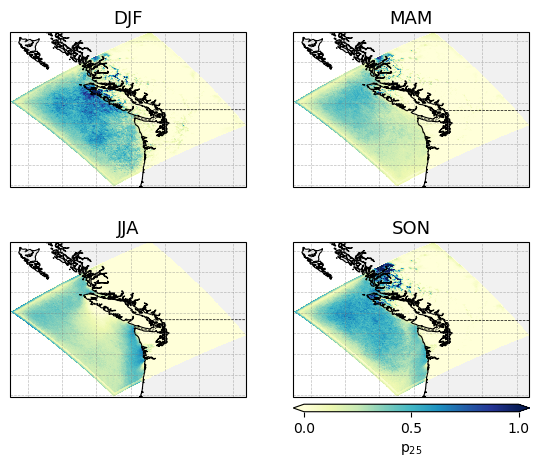

In [51]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Get lons and lats
lons = seasonal_p25.coords['lon'].values
lats = seasonal_p25.coords['lat'].values

# Define seasons in order
seasons = ['DJF', 'MAM', 'JJA', 'SON']

# Get consistent colorbar range across all seasons
vmin = seasonal_p25.min().values
vmax = 1#seasonal_p25.max().values

# --- Plot ---
fig, axes = plt.subplots(
    2, 2, figsize=(6.7, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, season in enumerate(seasons):
    ax = axes[i]
    
    data = seasonal_p25.sel(group=season)  # 'group' is default groupby name
    
    cf = ax.pcolormesh(
        lons, lats, data,
        cmap='YlGnBu',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    
    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                      alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = False
    
    ax.set_title(season, fontsize=13, fontweight='medium')

# --- Single colorbar ---

    if i == len(seasons) - 1:  # After last row in the column
        # Get position of the bottom axis in the column
        bbox = ax.get_position()
        # Create a new axis below it for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
            bbox.width, 0.015         # same width, small height
        ])
        cbar = fig.colorbar(cf, cax=cbar_ax, extend='both', orientation="horizontal")
        cbar.set_label('p$_{25}$', fontsize=10)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])


#plt.subplots_adjust(hspace=0.2, wspace=0.05) 

plt.savefig('seasonal_precip_maxp25.png', dpi=150, bbox_inches='tight')
plt.show()